## Viken KHATCHERIAN
## Formation AI Engineer
## Openclassrooms
## Projet 6 : initiez-vous au MLOps partie (1/2)
## Notebook 4 : 04_tracking_opt_hyperpar_model_seuil_mlflow_p6_vk
### ETAPE 4 : Optimiser les hyperparamètres et le seuil métier + tracking des expériences avec mlflow

In [2]:
# Importer les bibliothèques
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix
from sklearn.base import clone

import mlflow
import mlflow.sklearn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna

In [3]:
# Charger les données 
X_train = pd.read_parquet("X_train_ml.parquet")
y_train = pd.read_parquet("y_train_ml.parquet").squeeze()

print(X_train.shape, y_train.shape)
print(y_train.value_counts(normalize=True))

(307511, 250) (307511,)
TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64


In [4]:
# Configuration de mlflow
mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("P06_LightGBM_optimized")

<Experiment: artifact_location='file:///mnt/projects/ai_engineer_projects/P06/mlruns/7', creation_time=1780678827745, experiment_id='7', last_update_time=1780678827745, lifecycle_stage='active', name='P06_LightGBM_optimized', tags={}, trace_location=None, workspace='default'>

In [5]:
# Fonction de coût métier
def business_cost(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return 10 * fn + 1 * fp

In [6]:
# Probabilités out of fold pour la recherche du meilleur seuil de décision (sans data leakage)
def oof_predictions(model, X, y, cv):
    oof = np.zeros(len(y))

    for train_idx, val_idx in cv.split(X, y):

        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr = y.iloc[train_idx]

        m = clone(model)
        m.fit(X_tr, y_tr)

        oof[val_idx] = m.predict_proba(X_val)[:, 1]

    return oof

In [7]:
# Optimisation du seuil de décision
def optimize_threshold(y_true, y_prob):

    thresholds = np.linspace(0.05, 0.95, 50)

    costs = []
    f1s = []

    for t in thresholds:
        preds = (y_prob >= t).astype(int)

        costs.append(business_cost(y_true, preds))
        f1s.append(f1_score(y_true, preds))

    best_idx = np.argmin(costs)

    return thresholds[best_idx], costs, f1s, thresholds

In [8]:
# Setup du StratifierKold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [9]:
def objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 600),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1),
        "num_leaves": trial.suggest_int("num_leaves", 20, 80),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 80),
        "subsample": trial.suggest_float("subsample", 0.7, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 1.0),

        "scale_pos_weight": (len(y_train) - sum(y_train)) / sum(y_train),

        # stabilité CPU
        "n_jobs": 8,
        "random_state": 42,
        "verbose": -1
    }

    model = LGBMClassifier(**params)

    auc_scores = []

    for train_idx, val_idx in cv.split(X_train, y_train):

        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model.fit(X_tr, y_tr)
        preds = model.predict_proba(X_val)[:, 1]

        auc_scores.append(roc_auc_score(y_val, preds))

    return np.mean(auc_scores)


In [10]:
# Run Optuna
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)

best_params = study.best_params
print(best_params)


[I 2026-06-06 16:47:22,724] A new study created in memory with name: no-name-81fd28ea-8908-4cf1-9e15-054e35584bfc
[I 2026-06-06 16:47:50,096] Trial 0 finished with value: 0.7799901234813684 and parameters: {'n_estimators': 535, 'learning_rate': 0.021505403030526806, 'num_leaves': 50, 'max_depth': 7, 'min_child_samples': 71, 'subsample': 0.7472413717640031, 'colsample_bytree': 0.917194600393318}. Best is trial 0 with value: 0.7799901234813684.
[I 2026-06-06 16:48:04,957] Trial 1 finished with value: 0.776099739601858 and parameters: {'n_estimators': 342, 'learning_rate': 0.02994812064518676, 'num_leaves': 55, 'max_depth': 5, 'min_child_samples': 44, 'subsample': 0.9910988297879259, 'colsample_bytree': 0.897320787771285}. Best is trial 0 with value: 0.7799901234813684.
[I 2026-06-06 16:48:22,993] Trial 2 finished with value: 0.7786014254212852 and parameters: {'n_estimators': 330, 'learning_rate': 0.04411296787669529, 'num_leaves': 60, 'max_depth': 7, 'min_child_samples': 16, 'subsample'

{'n_estimators': 551, 'learning_rate': 0.0604879497641605, 'num_leaves': 20, 'max_depth': 6, 'min_child_samples': 80, 'subsample': 0.936158882138701, 'colsample_bytree': 0.7916235279314393}


2026/06/06 16:56:45 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/06 16:56:46 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/06 16:56:47 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
Successfully registered model 'P06_LightGBM_Optimized'.
2026/06/06 16:56:48 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: P06_LightGBM_Optimized, version 1
Created version '1' of model 'P06_LightGBM_Optimized'.


🏃 View run LightGBM_optimized_business at: http://127.0.0.1:5000/#/experiments/7/runs/71e82f1d4fc147099899ab0c7a48d17a
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/7


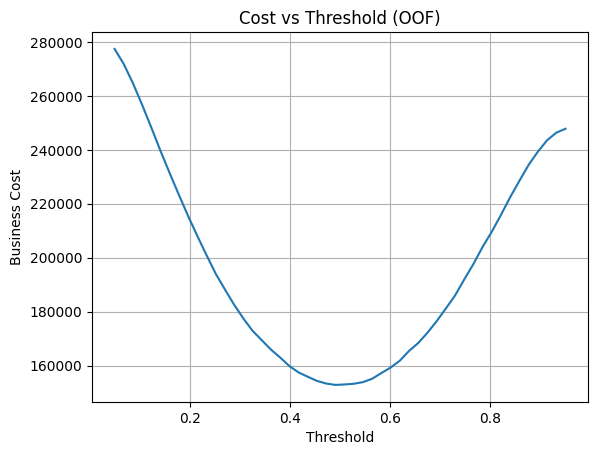

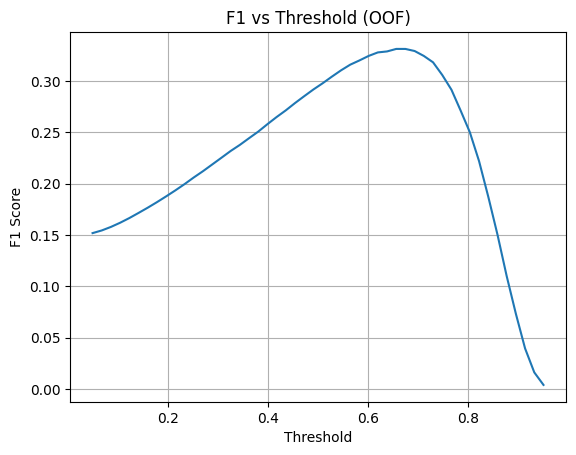

In [12]:
from mlflow import MlflowClient

# =========================
# FINAL MLflow RUN - STEP 4
# =========================
with mlflow.start_run(
    run_name="LightGBM_optimized_business"
) as run:

    # =========================
    # SCALE POS WEIGHT (déséquilibre classes)
    # =========================
    scale_pos = (len(y_train) - sum(y_train)) / sum(y_train)

    # =========================
    # MODEL
    # =========================
    best_model = LGBMClassifier(
        **best_params,
        scale_pos_weight=scale_pos,
        random_state=42,
        n_jobs=8,
        verbose=-1
    )

    # =========================
    # TAGS (UI MLflow)
    # =========================
    mlflow.set_tags({
        "project": "P06",
        "stage": "optimization",
        "model": "LightGBM",
        "selection_method": "Optuna + CV + business cost",
        "imbalance_handling": "scale_pos_weight",
        "cv_strategy": "StratifiedKFold",
        "primary_metric": "business_cost_oof"
    })

    mlflow.set_tag(
    "mlflow.note.content",
    """
    Optimisation du modèle LightGBM avec Optuna.

    Hyperparamètres optimisés via validation croisée stratifiée 5 folds.

    Gestion du déséquilibre via scale_pos_weight.

    Recherche du seuil optimal basée sur une fonction de coût métier
    pondérant les Faux Négatifs 10 fois plus fortement que les Faux Positifs.

    Sélection finale basée sur business_cost_oof.
    """
    )

    # =========================
    # PARAMS (TRACEABILITÉ)
    # =========================
    mlflow.log_params(best_params)
    mlflow.log_param("scale_pos_weight", scale_pos)
    mlflow.log_param("cv_folds", 5)
    mlflow.log_param("optuna_best_trial", study.best_trial.number)
    mlflow.log_param("n_features", X_train.shape[1])
    mlflow.log_param("n_samples", len(X_train))

    # =========================
    # CV SCORE (AUC)
    # =========================
    aucs = []

    for train_idx, val_idx in cv.split(X_train, y_train):

        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        # IMPORTANT: modèle indépendant par fold (anti leakage)
        fold_model = LGBMClassifier(
            **best_params,
            scale_pos_weight=scale_pos,
            random_state=42,
            n_jobs=8,
            verbose=-1
        )

        fold_model.fit(X_tr, y_tr)
        preds = fold_model.predict_proba(X_val)[:, 1]

        aucs.append(roc_auc_score(y_val, preds))

    auc_mean = np.mean(aucs)

    # =========================
    # OOF PREDICTIONS (ANTI LEAKAGE)
    # =========================
    oof = oof_predictions(best_model, X_train, y_train, cv)

    # =========================
    # THRESHOLD OPTIMIZATION (BUSINESS)
    # =========================
    best_threshold, costs, f1s, thresholds = optimize_threshold(y_train, oof)

    # =========================
    # BUSINESS COST FINAL (OOF ONLY → NO LEAKAGE)
    # =========================
    final_pred_oof = (oof >= best_threshold).astype(int)
    final_cost = business_cost(y_train, final_pred_oof)

    # =========================
    # MLflow METRICS (IMPORTANT POUR CHAMPION SELECTION)
    # =========================
    mlflow.log_metric("cv_auc_mean", auc_mean)
    mlflow.log_metric("business_cost_oof", final_cost)
    mlflow.log_metric("best_threshold", best_threshold)

    # métriques secondaires utiles UI
    mlflow.log_metric("cost_reduction_signal", -final_cost)
    mlflow.log_metric("n_features", X_train.shape[1])
    mlflow.log_metric("n_samples", len(X_train))

    # =========================
    # ARTIFACTS (CURVES MÉTIER)
    # =========================
    plt.figure()
    plt.plot(thresholds, costs)
    plt.xlabel("Threshold")
    plt.ylabel("Business Cost")
    plt.title("Cost vs Threshold (OOF)")
    plt.grid()
    plt.savefig("cost_vs_threshold.png")
    mlflow.log_artifact("cost_vs_threshold.png")

    plt.figure()
    plt.plot(thresholds, f1s)
    plt.xlabel("Threshold")
    plt.ylabel("F1 Score")
    plt.title("F1 vs Threshold (OOF)")
    plt.grid()
    plt.savefig("f1_vs_threshold.png")
    mlflow.log_artifact("f1_vs_threshold.png")

    # =========================
    # FINAL MODEL TRAIN (READY FOR REGISTRY)
    # =========================
    best_model.fit(X_train, y_train)

    result = mlflow.sklearn.log_model(
    best_model,
    artifact_path="model",
    registered_model_name="P06_LightGBM_Optimized"
    )

    model_version = result.registered_model_version

In [13]:
from mlflow import MlflowClient

client = MlflowClient()

client.update_model_version(
    name="P06_LightGBM_Optimized",
    version=1,
    description="""
    LightGBM optimisé avec Optuna.

    Validation croisée stratifiée 5 folds.

    Déséquilibre traité via scale_pos_weight.

    Seuil métier optimisé sur prédictions OOF.

    Modèle retenu pour minimiser le coût métier.
    """
)

client.set_model_version_tag(
    name="P06_LightGBM_Optimized",
    version=1,
    key="stage",
    value="optimization"
)

client.set_model_version_tag(
    name="P06_LightGBM_Optimized",
    version=1,
    key="project",
    value="P06"
)

client.set_model_version_tag(
    name="P06_LightGBM_Optimized",
    version=1,
    key="primary_metric",
    value="business_cost_oof"
)

client.set_registered_model_alias(
    name="P06_LightGBM_Optimized",
    alias="champion",
    version=1
)

- L’étape 3 a permis de sélectionner LightGBM comme meilleur compromis performance / coût métier.
- L’étape 4 a ensuite optimisé ce modèle via Optuna et ajustement du seuil de décision basé sur les probabilités out-of-fold afin de minimiser le coût métier (FN fortement pénalisés).”

### Démarche utilisée pour obtenir le meilleur modèle

- Les hyperparamètres ont été optimisés avec Optuna en maximisant la ROC-AUC, car cette métrique évalue la capacité discriminante intrinsèque du modèle indépendamment du seuil de décision.
- Une fois le meilleur modèle obtenu, le seuil de classification a été optimisé séparément à l’aide d’une fonction de coût métier attribuant un poids plus important aux faux négatifs qu’aux faux positifs.
- Cette approche permet de dissocier l’optimisation du modèle de l’optimisation de la décision métier.

Si la recherche du meilleur modèle avec optuna avait été faite sur le coût métier il aurait fallu:

- choisir le seuil pendant l'optimisation du modèle ce qui revient à mélanger optimisation du modèle et optimisation de la décision métier
- les résultats de prédiction obtenus auraient alors été bruités et plus instables.

**C'est pourquoi l'approche a été séparée en optimisant d'abord les hyperparamètres vis à vis du ROC-AUC puis en recherchant le meilleur seuil de décision c'est-à-dire celui minimisant la fonction de coût métier.**

### Comparaison des résultats avec le modèle LightGBM de l'étape 3

- A l'étape 3 on a un coût métier moyen par fold de 30 769 sachant que le dataset a été splitté en 5 folds.
- **A l'étape 4 on a coût métier out-of-fold de 152 815 soit moins que 5 x 30 769 = 153 845 à l'étape 3.**
- Donc on peut dire que l'étape 4 a permis d'obtenir un modèle optimisé diminuant le coût métier.
- **Cette diminution, bien que modeste, montre que l’optimisation des hyperparamètres et surtout l’ajustement du seuil de décision en fonction d’une fonction de coût pénalisant fortement les faux négatifs permettent d’obtenir un modèle mieux aligné avec les enjeux métier.**

**La valeur de l'AUC est passée de 0.7797 (étape 3) à 0.7806 (étape 4) avec le modèle optimisé à l'étape 4.**
- L’étape 4 a permis d’améliorer légèrement la performance du modèle LightGBM. L’AUC moyenne en validation croisée est passée de 0,7797 à 0,7806 après optimisation des hyperparamètres via Optuna et ajustement du seuil de décision.
- Bien que le gain en AUC soit marginal, l’étape 4 apporte surtout une amélioration plus significative du point de vue métier grâce à l’optimisation du seuil basé sur une fonction de coût pénalisant fortement les faux négatifs.



